In [ ]:
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!wget https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
!tar -xvf spark-3.5.1-bin-hadoop3.tgz
!pip install -q findspark

--2026-04-29 17:42:35--  https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
Resolving archive.apache.org (archive.apache.org)... 65.108.204.189, 2a01:4f9:1a:a084::2
Connecting to archive.apache.org (archive.apache.org)|65.108.204.189|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 400446614 (382M) [application/x-gzip]
Saving to: ‘spark-3.5.1-bin-hadoop3.tgz.1’

spark-3.5.1-bin-had 100%[===================>] 381.90M   598KB/s    in 7m 54s  

2026-04-29 17:50:30 (826 KB/s) - ‘spark-3.5.1-bin-hadoop3.tgz.1’ saved [400446614/400446614]

spark-3.5.1-bin-hadoop3/
spark-3.5.1-bin-hadoop3/sbin/
spark-3.5.1-bin-hadoop3/sbin/spark-config.sh
spark-3.5.1-bin-hadoop3/sbin/stop-slave.sh
spark-3.5.1-bin-hadoop3/sbin/stop-mesos-dispatcher.sh
spark-3.5.1-bin-hadoop3/sbin/start-workers.sh
spark-3.5.1-bin-hadoop3/sbin/start-slaves.sh
spark-3.5.1-bin-hadoop3/sbin/start-all.sh
spark-3.5.1-bin-hadoop3/sbin/stop-all.sh
spark-3.5.1-bin-hadoop3/sbin/workers.

In [ ]:
import os
import findspark

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"

findspark.init()

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MentalHealth") \
    .getOrCreate()

print("Spark Working!")

Spark شغال 🔥


In [ ]:
df = spark.read.csv("/content/Mental Health Dataset.csv", header=True, inferSchema=True)

In [ ]:
df.show(5)
df.printSchema()

+---------------+------+-------------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|      Timestamp|Gender|      Country|Occupation|self_employed|family_history|treatment|Days_Indoors|Growing_Stress|Changes_Habits|Mental_Health_History|Mood_Swings|Coping_Struggles|Work_Interest|Social_Weakness|mental_health_interview|care_options|
+---------------+------+-------------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|8/27/2014 11:29|Female|United States| Corporate|         NULL|            No|      Yes|   1-14 days|           Yes|            No|                  Yes|     Medium|              No|           No|            Yes|                     No|    Not sure|


In [ ]:
df.describe().show()

+-------+---------------+------+-------------+----------+-------------+--------------+---------+------------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|summary|      Timestamp|Gender|      Country|Occupation|self_employed|family_history|treatment|      Days_Indoors|Growing_Stress|Changes_Habits|Mental_Health_History|Mood_Swings|Coping_Struggles|Work_Interest|Social_Weakness|mental_health_interview|care_options|
+-------+---------------+------+-------------+----------+-------------+--------------+---------+------------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|  count|         292364|292364|       292364|    292364|       287162|        292364|   292364|            292364|        292364|        292364|               292364|     292364|          292364|       29236

In [ ]:
from pyspark.sql.functions import col, count, when

df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

+---------+------+-------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|Timestamp|Gender|Country|Occupation|self_employed|family_history|treatment|Days_Indoors|Growing_Stress|Changes_Habits|Mental_Health_History|Mood_Swings|Coping_Struggles|Work_Interest|Social_Weakness|mental_health_interview|care_options|
+---------+------+-------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|        0|     0|      0|         0|         5202|             0|        0|           0|             0|             0|                    0|          0|               0|            0|              0|                      0|           0|
+---------+------+-------+----------+-----------

In [ ]:
df.groupBy("Growing_Stress").count().show()

+--------------+-----+
|Growing_Stress|count|
+--------------+-----+
|         Maybe|99985|
|            No|92726|
|           Yes|99653|
+--------------+-----+



In [ ]:
df.groupBy("Growing_Stress", "treatment").count().show()

+--------------+---------+-----+
|Growing_Stress|treatment|count|
+--------------+---------+-----+
|           Yes|      Yes|51012|
|         Maybe|      Yes|49965|
|            No|       No|46097|
|           Yes|       No|48641|
|            No|      Yes|46629|
|         Maybe|       No|50020|
+--------------+---------+-----+



In [ ]:
df.groupBy("Country").count().orderBy("count", ascending=False).show()

+--------------+------+
|       Country| count|
+--------------+------+
| United States|171308|
|United Kingdom| 51404|
|        Canada| 18726|
|     Australia|  6026|
|   Netherlands|  5894|
|       Ireland|  5548|
|       Germany|  4680|
|        Sweden|  2818|
|         India|  2774|
|        France|  2340|
|        Brazil|  2340|
|   New Zealand|  1994|
|  South Africa|  1994|
|         Italy|  1560|
|        Israel|  1560|
|   Switzerland|  1560|
|       Belgium|   824|
|        Poland|   824|
|        Russia|   780|
|     Singapore|   780|
+--------------+------+
only showing top 20 rows



In [ ]:
pdf = df.toPandas()

In [ ]:
df

DataFrame[Timestamp: string, Gender: string, Country: string, Occupation: string, self_employed: string, family_history: string, treatment: string, Days_Indoors: string, Growing_Stress: string, Changes_Habits: string, Mental_Health_History: string, Mood_Swings: string, Coping_Struggles: string, Work_Interest: string, Social_Weakness: string, mental_health_interview: string, care_options: string]

In [ ]:
from pyspark.sql.functions import col

df = df.dropna()

In [ ]:
from pyspark.sql.functions import lower

df = df.withColumn("Gender", lower(col("Gender")))

# **Feature Engineering**

In [ ]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="Gender", outputCol="Gender_index")
df = indexer.fit(df).transform(df)

In [ ]:
cols = ["Country", "Occupation", "Growing_Stress", "Mood_Swings"]

for c in cols:
    indexer = StringIndexer(inputCol=c, outputCol=c + "_index")
    df = indexer.fit(df).transform(df)

# **Machine Learning**

In [ ]:
indexer_treatment = StringIndexer(inputCol="treatment", outputCol="treatment_index")
df = indexer_treatment.fit(df).transform(df)

In [ ]:
train, test = df.randomSplit([0.8, 0.2])

# **logestic regresstion**

In [ ]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="features_v2", labelCol="treatment_index")
model = lr.fit(train)

In [ ]:
predictions = model.transform(test)
predictions.select("features_v2", "treatment_index", "prediction").show()

+--------------------+---------------+----------+
|         features_v2|treatment_index|prediction|
+--------------------+---------------+----------+
|[1.0,0.0,4.0,1.0,...|            0.0|       0.0|
|[1.0,0.0,4.0,0.0,...|            0.0|       0.0|
|[1.0,0.0,4.0,2.0,...|            0.0|       0.0|
|[1.0,0.0,4.0,2.0,...|            0.0|       0.0|
|[1.0,0.0,4.0,1.0,...|            0.0|       0.0|
|[1.0,0.0,4.0,1.0,...|            0.0|       0.0|
|[1.0,0.0,4.0,0.0,...|            0.0|       0.0|
|[1.0,0.0,4.0,0.0,...|            0.0|       0.0|
|[1.0,0.0,4.0,2.0,...|            0.0|       0.0|
|[1.0,0.0,4.0,2.0,...|            0.0|       0.0|
|[1.0,0.0,4.0,2.0,...|            0.0|       0.0|
|[1.0,0.0,2.0,0.0,...|            0.0|       0.0|
|[1.0,0.0,2.0,1.0,...|            0.0|       0.0|
|[1.0,0.0,2.0,1.0,...|            0.0|       0.0|
|[1.0,0.0,2.0,1.0,...|            0.0|       0.0|
|(12,[0,2,4,9,10,1...|            0.0|       0.0|
|[1.0,0.0,2.0,1.0,...|            0.0|       0.0|


In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(labelCol="treatment_index")
print("Accuracy:", evaluator.evaluate(predictions))

Accuracy: 0.7148245046828535


In [ ]:
pdf = df.toPandas()

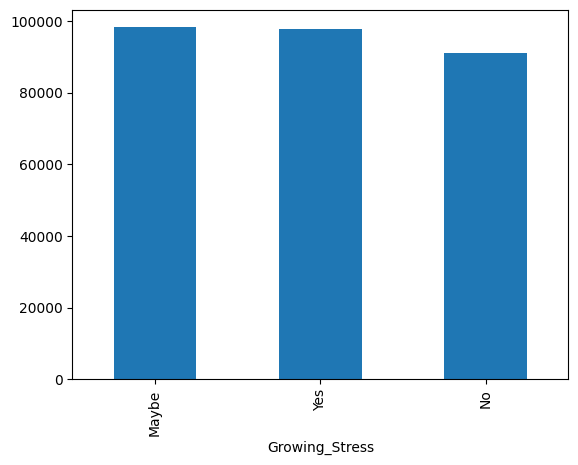

In [ ]:
import matplotlib.pyplot as plt

pdf["Growing_Stress"].value_counts().plot(kind="bar")
plt.show()

In [ ]:
from pyspark.ml.feature import OneHotEncoder

encoder = OneHotEncoder(
    inputCols=["Gender_index"],
    outputCols=["Gender_vec"]
)
df = encoder.fit(df).transform(df)

## **RandomForest**

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features_v2",
    labelCol="treatment_index",
    numTrees=200,
    maxBins=64
)

model = rf.fit(train)

In [ ]:
predictions = model.transform(test)
predictions.show(5)

+---------------+------+-------------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+------------+-------------+----------------+--------------------+-----------------+-------------+---------------+----------+--------------+--------------+----------------+----------------------+-------------------+---------------------+--------------------+------------------+---------------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+
|      Timestamp|Gender|      Country|Occupation|self_employed|family_history|treatment|Days_Indoors|Growing_Stress|Changes_Habits|Mental_Health_History|Mood_Swings|Coping_Struggles|Work_Interest|Social_Weakness|mental_health_interview|care_options|Gender_index|Country_index|Occupation_index|Growing_Stress_index|Mood_Swings_inde

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="treatment_index",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)
print("Accuracy:", accuracy)

Accuracy: 0.6871103504880988


In [ ]:
model.featureImportances

SparseVector(3, {0: 0.9989, 1: 0.0008, 2: 0.0004})

In [ ]:
df.groupBy("treatment").count().show()

+---------+------+
|treatment| count|
+---------+------+
|       No|142418|
|      Yes|144744|
+---------+------+



In [ ]:
from pyspark.ml.feature import OneHotEncoder

encoder = OneHotEncoder(
    inputCols=["Country_index", "Occupation_index"],
    outputCols=["Country_vec", "Occupation_vec"]
)

df = encoder.fit(df).transform(df)

In [ ]:
# Index the remaining categorical columns
columns_to_index = [
    "Coping_Struggles", "Work_Interest", "Social_Weakness",
    "Changes_Habits", "Days_Indoors", "Mental_Health_History",
    "family_history"
]

for col_name in columns_to_index:
    indexer = StringIndexer(inputCol=col_name, outputCol=col_name + "_index")
    df = indexer.fit(df).transform(df)

In [ ]:
print(df.columns)

['Timestamp', 'Gender', 'Country', 'Occupation', 'self_employed', 'family_history', 'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options', 'Gender_index', 'Country_index', 'Occupation_index', 'Growing_Stress_index', 'Mood_Swings_index', 'features', 'treatment_index', 'Gender_vec', 'Country_vec', 'Occupation_vec', 'treatment_output', 'Coping_Struggles_index', 'Work_Interest_index', 'Social_Weakness_index', 'Changes_Habits_index', 'Days_Indoors_index', 'Mental_Health_History_index', 'family_history_index', 'all_features']


In [ ]:
features = [
    "Gender_index",
    "Country_index",
    "Occupation_index",
    "Growing_Stress_index",
    "Mood_Swings_index",
    "Coping_Struggles_index",
    "Work_Interest_index",
    "Social_Weakness_index",
    "Changes_Habits_index",
    "Days_Indoors_index",
    "mental_health_history_index",
    "family_history_index"
]

In [ ]:
from pyspark.ml.feature import VectorAssembler

# Correcting the case of the column name in the features list
features = [
    "Gender_index",
    "Country_index",
    "Occupation_index",
    "Growing_Stress_index",
    "Mood_Swings_index",
    "Coping_Struggles_index",
    "Work_Interest_index",
    "Social_Weakness_index",
    "Changes_Habits_index",
    "Days_Indoors_index",
    "Mental_Health_History_index",
    "family_history_index"
]

assembler = VectorAssembler(
    inputCols=features,
    outputCol="features_v2"
)

df = assembler.transform(df)

In [ ]:
df.select("features_v2").show(1, truncate=False)

+-------------------------------------------------+
|features_v2                                      |
+-------------------------------------------------+
|[1.0,0.0,2.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,1.0]|
+-------------------------------------------------+
only showing top 1 row



## **GbT(Gradint boosted trees)**

In [ ]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    labelCol="treatment_index",
    featuresCol="features_v2",
    maxIter=50,      # عدد الأشجار (iterations)
    maxDepth=5,
    maxBins=64 # عمق الشجرة (مهم لتجنب overfitting)
)

model = gbt.fit(train)

In [ ]:
predictions = model.transform(test)
predictions.show(5)

+---------------+------+-------------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+------------+-------------+----------------+--------------------+-----------------+-------------+---------------+----------+--------------+--------------+----------------+----------------------+-------------------+---------------------+--------------------+------------------+---------------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+
|      Timestamp|Gender|      Country|Occupation|self_employed|family_history|treatment|Days_Indoors|Growing_Stress|Changes_Habits|Mental_Health_History|Mood_Swings|Coping_Struggles|Work_Interest|Social_Weakness|mental_health_interview|care_options|Gender_index|Country_index|Occupation_index|Growing_Stress_index|Mood_Swings_inde

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="treatment_index",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)
print("GBT Accuracy:", accuracy)

GBT Accuracy: 0.6975883205560309


In [ ]:
f1 = MulticlassClassificationEvaluator(
    labelCol="treatment_index",
    predictionCol="prediction",
    metricName="f1"
).evaluate(predictions)

print("GBT F1 Score:", f1)

GBT F1 Score: 0.6952094990832745


In [ ]:
df.write.mode("overwrite").parquet("/content/processed_data")

## **Analytics / Machine Learning pipline**

In [ ]:
# Logistic Regression
lr_model = lr.fit(train)

# Random Forest
rf_model = rf.fit(train)

# GBT
gbt_model = gbt.fit(train)

# **Visualization Layer**

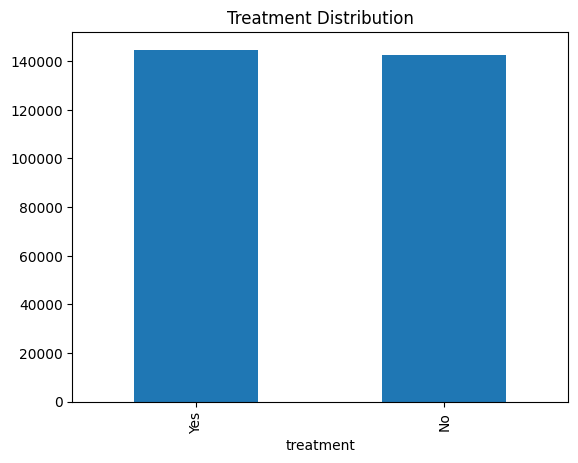

In [ ]:
import matplotlib.pyplot as plt

pdf = df.toPandas()

pdf["treatment"].value_counts().plot(kind="bar")
plt.title("Treatment Distribution")
plt.show()

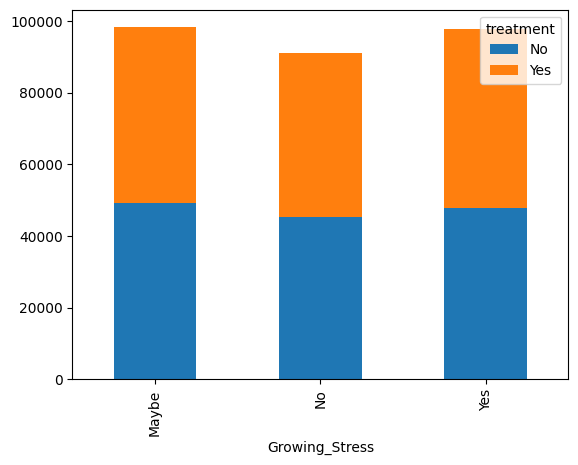

In [ ]:
pdf.groupby("Growing_Stress")["treatment"].value_counts().unstack().plot(kind="bar", stacked=True)
plt.show()

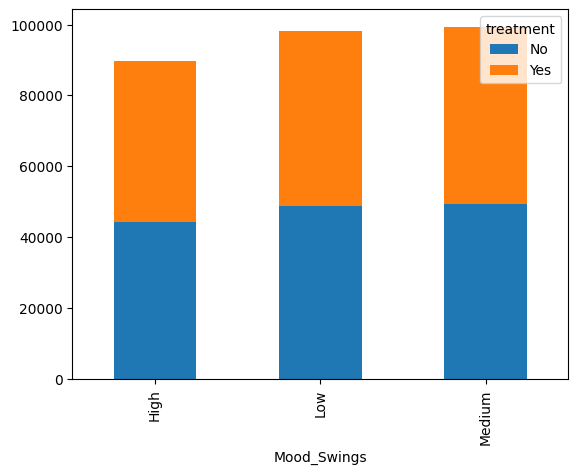

In [ ]:
pdf.groupby("Mood_Swings")["treatment"].value_counts().unstack().plot(kind="bar", stacked=True)
plt.show()

In [ ]:
from google.colab import files
files.download("processed_data")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Save to CSV to use in power bi**

In [ ]:
df_save = df.drop(
    "features",
    "features_v2",
    "Gender_vec",
    "Country_vec",
    "Occupation_vec",
    "all_features"
)

In [ ]:
from pyspark.sql.functions import col

df_clean = predictions.select(
    "Gender",
    "Country",
    "Occupation",
    "Growing_Stress",
    "Mood_Swings",
    "Coping_Struggles",
    "Work_Interest",
    "Social_Weakness",
    "Changes_Habits",
    "Days_Indoors",
    "family_history",
    "Mental_Health_History",
    "treatment",
    "prediction"
)

In [ ]:
df_clean.write.mode("overwrite").csv("/content/powerbi_data", header=True)